# **ICT303 - Advanced Machine Learning and Artificial Intelligence**
# **Topic 8 - Recurrent Neural Networks (RNNs)**

This tutorial demonstrates how to implement and use Recurrent Neural Networks (RNNs). We will first start with a the implementatiom from scratch of a simple RNN. Then, we will use PyTorch libraries to rtain a Long Short-Term Memory (LSTM) network. LSTMs are widely used for processing sequential data such as text, videos, etc..

This tutorial is adapted from [Chapter 9](https://d2l.ai/chapter_recurrent-neural-networks/index.html) and  [Chapter 10](https://classic.d2l.ai/chapter_convolutional-neural-networks/index.html) of the textbook.

## **1. Simple RNN from scratch**

This tutorial is adapted from [this PyTorch tutorial on classifying names](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html). Specifically, we build and train a simple RNN that takes surnames and predicts which language the name is from based on its spelling. We consider $18$ languages.

### **1.1. Data preparation**

First, download the data from [here](https://download.pytorch.org/tutorial/data.zip) and extract it into the current directory. In my case, I named the folder `language_data`. You will notice that the directory `language_data/name` contains $18$ text files (one for each language) named as `[Language].txt`. Each file contains a bunch of names, one name per line, mostly romanized (but we still need to convert from Unicode to ASCII).

First, we need to:
- Convert the names from Unicode into ASCII.
- Build up a dictionary of names per language, in the form `{language: [name1, name2, ...]}`.



In [ ]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob   # short for global. It is used to return all file paths that match a specific pattern.
import os
from google.colab import drive

file_path = '/content/data/names/*.txt'
# file_path = 'drive/My Drive/Colab Notebooks/ICT303/language_data/names/*.txt'

# Find all file names within a given path
def findFiles(path):
  return glob.glob(path)

# You just need to run the comman below once
# drive.mount('/content/drive') # No longer needed if the data is in the current directory

# Testing
print(findFiles(file_path))

['/content/data/names/Irish.txt', '/content/data/names/Vietnamese.txt', '/content/data/names/Chinese.txt', '/content/data/names/German.txt', '/content/data/names/Dutch.txt', '/content/data/names/Greek.txt', '/content/data/names/French.txt', '/content/data/names/Italian.txt', '/content/data/names/Japanese.txt', '/content/data/names/Scottish.txt', '/content/data/names/Polish.txt', '/content/data/names/Korean.txt', '/content/data/names/Russian.txt', '/content/data/names/Czech.txt', '/content/data/names/Spanish.txt', '/content/data/names/English.txt', '/content/data/names/Arabic.txt', '/content/data/names/Portuguese.txt']


Next, we write a function that turns Unicode strings into plain ASCII.

In [ ]:
import unicodedata
import string

# Turning Unicode string to pain ASCII
all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

Slusarski


Finally, we would like to build the `category_lines` dictionary, which is a list of names per language.

In [ ]:
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles(file_path):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

## Just for test
# print all the Chinese names
print(category_lines['Chinese'])

# Print only the first 5 Chinese names
print(category_lines['Chinese'][:5])

['Ang', 'AuYong', 'Bai', 'Ban', 'Bao', 'Bei', 'Bian', 'Bui', 'Cai', 'Cao', 'Cen', 'Chai', 'Chaim', 'Chan', 'Chang', 'Chao', 'Che', 'Chen', 'Cheng', 'Cheung', 'Chew', 'Chieu', 'Chin', 'Chong', 'Chou', 'Chu', 'Cui', 'Dai', 'Deng', 'Ding', 'Dong', 'Dou', 'Duan', 'Eng', 'Fan', 'Fei', 'Feng', 'Foong', 'Fung', 'Gan', 'Gauk', 'Geng', 'Gim', 'Gok', 'Gong', 'Guan', 'Guang', 'Guo', 'Gwock', 'Han', 'Hang', 'Hao', 'Hew', 'Hiu', 'Hong', 'Hor', 'Hsiao', 'Hua', 'Huan', 'Huang', 'Hui', 'Huie', 'Huo', 'Jia', 'Jiang', 'Jin', 'Jing', 'Joe', 'Kang', 'Kau', 'Khoo', 'Khu', 'Kong', 'Koo', 'Kwan', 'Kwei', 'Kwong', 'Lai', 'Lam', 'Lang', 'Lau', 'Law', 'Lew', 'Lian', 'Liao', 'Lim', 'Lin', 'Ling', 'Liu', 'Loh', 'Long', 'Loong', 'Luo', 'Mah', 'Mai', 'Mak', 'Mao', 'Mar', 'Mei', 'Meng', 'Miao', 'Min', 'Ming', 'Moy', 'Mui', 'Nie', 'Niu', 'OuYang', 'OwYang', 'Pan', 'Pang', 'Pei', 'Peng', 'Ping', 'Qian', 'Qin', 'Qiu', 'Quan', 'Que', 'Ran', 'Rao', 'Rong', 'Ruan', 'Sam', 'Seah', 'See ', 'Seow', 'Seto', 'Sha', 'Shan', 'Sh

**Next**, we need to turn the names into Tensors so that we can use them. We use "on-hot-vector" representation. For example, when we have an alphabet of $26$ characters (which is the case in English), we represent each letter of the alphabet as a vector of length  $26$. It will be filled with zeros except for the one at the index of the current letter. For example, the letter "b" will be represented as `<0 1 0 0 ...>`.

To make a word, e.g., `Hamid`, we join the one-hot-vectors of each of the letters into a 2D matrix of size `word_length X 1 X n_alphabet_letters`. The extra 1 dimension is because PyTorch assumes everything is in batches - we’re just using a batch size of 1 here.

In [ ]:
import torch

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

## Testing
print(letterToTensor('J'))

print(lineToTensor('Jones').size())

print(lineToTensor('Jones'))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])
tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0.,

### **1.2. Creating the network**
We will use a simple RNN module which takes the input and the hidden state,  concatenates them, and feeds them into:
- The input-to-output branch (i2o) composed of a linear layer followed by a LogSoftMax layer (activation function) to produce the output
- The input-to-hidden branch (i2h) composed of a linear layer. It outputs the hidden state, which is fed back to the network (the recurrent loop).

The code below shows how to create such RNN module.

In [ ]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, lr):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.lr = lr

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
      # Note here that the forward step takes as input the input and the hidden state
      # It then combines them bby concatenation before feeding them to the network
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        # the hidden state needs to be initialized (for the firs iteration)
        return torch.zeros(1, self.hidden_size)

    ## The loss function - Here, we will use Negative Log Likelihood
    def loss(self, y_hat, y):
      fn = nn.NLLLoss()
      return fn(y_hat, y)

    ## The optimization algorithm
    def configure_optimizers(self):
      return torch.optim.Adam(self.parameters(), self.lr)

    def evaluate(self, line_tensor):
      hidden  = self.initHidden()

      for i in range(line_tensor.size()[0]):
        output, hidden = self.forward(line_tensor[i], hidden)

      return output



Let's do a quick test;

In [ ]:
# print(n_letters)
# print(n_categories)

# size of the hidden state
n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories, lr = 0.01)

To run a step of this network we need to pass an input (in our case, the Tensor for the current letter) and a previous hidden state (which we initialize as zeros at first).

In [ ]:
input = lineToTensor('Albert')
# As it is the first step, we need to initialize the hidden layer
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)  # jst runninh through the first character

print(output)

tensor([[-2.9236, -2.9163, -2.9960, -2.8386, -2.8885, -2.8047, -2.9045, -2.9299,
         -2.8335, -2.9233, -2.8488, -2.9535, -2.8524, -2.8403, -2.8642, -2.8717,
         -2.9191, -2.9393]], grad_fn=<LogSoftmaxBackward0>)


By running the code above, you will notice that the output is a Tensor of size `1 X n_categories`, where every item is the likelihood of that category (higher is more likely). This, however, is not interpretable. In fact, we need to get from that output, the index of the element that has the maximum likelihood and use that index to find the name of the corresponding language.  This can be done using the following helper function:

In [ ]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))


('Greek', 5)


### **1.3. Training**
Each loop of training,
- Creates input and target tensors
- Creates a zeroed initial hidden state
- Reads each letter in and
- Keeps hidden state for next letter
- Compares final output to target
- Back-propagates the gradient
- Returns the output and loss

Let's first make a mechanism for picking random training samples from our  training dataset.

In [ ]:
# A mechanism for picking a random training sample
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample(all_categories, category_lines):
    # pick up a random language
    category = randomChoice(all_categories)

    # pick up a random name from that language
    line = randomChoice(category_lines[category])

    # Convert the picked data into a tensor
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)

    return category, line, category_tensor, line_tensor

## Let's test it
for i in range(1):
    category, line, category_tensor, line_tensor = randomTrainingExample(all_categories, category_lines)
    print('category =', category, '/ line =', line)
    # print(category_tensor)
    # print(line_tensor)

category = Dutch / line = Mooren


Now, let's create the training class.

In [ ]:
import time
import math

def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

## The training loop
class Trainer:

  def __init__(self, n_epochs = 1):
    self.max_epochs = n_epochs
    # self.writer     = tb  # the tensorboard instance

    # Setting the default device
    self.device = get_default_device()
    return

  # A helper function to setup a given device
  def set_device(self, device):
    self.device = device
    return

  def fit(self, model, all_categories, category_lines):

    self.current_loss = 0
    self.all_losses   = []

    self.all_categories = all_categories
    self.category_lines = category_lines

    # Trasnfer the model to the device (GPU or CPU)
    model.to(self.device)

    # configure the optimizer
    self.optimizer = model.configure_optimizers()
    self.model     = model

    self.start = time.time()

    for epoch in range(self.max_epochs):
      self.fit_epoch()

      # Logging the average training loss so that it can be visualized in the tensorboard
      # self.writer.add_scalar("Training Loss", self.avg_training_loss, epoch)

    print("Training process has finished")

  def fit_epoch(self):

    n_iters = 100000;
    print_every = 5000
    plot_every  = 1000

    self.current_loss = 0.0
    self.all_losses = []

    # self.avg_training_loss = 0.0

    # iterate over the DataLoader for training data
    for iter in range(1, n_iters+1):

      ## Get input
      category, line, category_tensor, line_tensor = randomTrainingExample(all_categories, category_lines)

      ## training
      hidden = self.model.initHidden()

      # Clear gradient buffers because we don't want any gradient from previous
      # epoch to carry forward, dont want to cummulate gradients
      self.optimizer.zero_grad()

      # get output from the model, given the inputs
      for i in range(line_tensor.size()[0]):
          output, hidden = self.model(line_tensor[i], hidden)

      # get loss for the predicted output
      loss = self.model.loss(output, category_tensor)

      # get gradients w.r.t to the parameters of the model
      loss.backward()

      # update the parameters (perform optimization)
      self.optimizer.step()

      ## Let's print some statistics - Gradient is not required from here
      with torch.no_grad():
        self.current_loss += loss

        # Print the iteration no., loss, name and guess
        if iter % print_every == 0:
          guess, guess_i = categoryFromOutput(output)

          correct = '✓' if guess == category else '✗ (%s)' % category
          print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(self.start), loss, line, guess, correct))

        # Add current loss avg to list of losses (avergae loss of "plot_every" iterations)
        if iter % plot_every == 0:
            self.all_losses.append(self.current_loss / plot_every)
            self.current_loss = 0

Now, we have all what we need to train the network.

In [ ]:
## 2. The RNN model
n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories, lr=1e-04)

# 3. Training the network
# 3.1. Creating the trainer class - note that here, I passed writer as a  parameter to the trainer
trainer = Trainer(n_epochs=1)

# 3.2. Training the model
trainer.fit(rnn, all_categories, category_lines)

5000 5% (0m 8s) 2.1839 Vaculova / Czech ✓
10000 10% (0m 16s) 2.8707 Papke / Polish ✗ (German)
15000 15% (0m 23s) 2.8323 Gosselin / Greek ✗ (French)
20000 20% (0m 30s) 2.3087 Haidin / Arabic ✗ (Russian)
25000 25% (0m 37s) 1.3536 Stevenson / Scottish ✓
30000 30% (0m 45s) 1.1066 Kassis / Arabic ✓
35000 35% (0m 52s) 2.0326 Hajkova / Japanese ✗ (Czech)
40000 40% (0m 59s) 1.2037 Totah / Arabic ✓
45000 45% (1m 6s) 0.4950 Henderson / Scottish ✓
50000 50% (1m 14s) 1.9432 Roma / Spanish ✓
55000 55% (1m 21s) 2.0162 Krol / Scottish ✗ (Polish)
60000 60% (1m 28s) 0.4738 Khoury / Arabic ✓
65000 65% (1m 35s) 2.4789 Howie / Korean ✗ (English)
70000 70% (1m 43s) 0.7260 Yin / Korean ✗ (Chinese)
75000 75% (1m 50s) 2.3926 Michel / German ✗ (Polish)
80000 80% (1m 57s) 1.8735 Rosa / Spanish ✗ (Italian)
85000 85% (2m 5s) 0.2187 Kitoaji / Japanese ✓
90000 90% (2m 12s) 1.0934 Hermann / German ✓
95000 95% (2m 19s) 1.6422 Protz / Spanish ✗ (German)
100000 100% (2m 27s) 0.4471 Ruadhain / Irish ✓
Training process h

**Plotting the results**

Plotting the historical loss from all_losses shows the network learning.

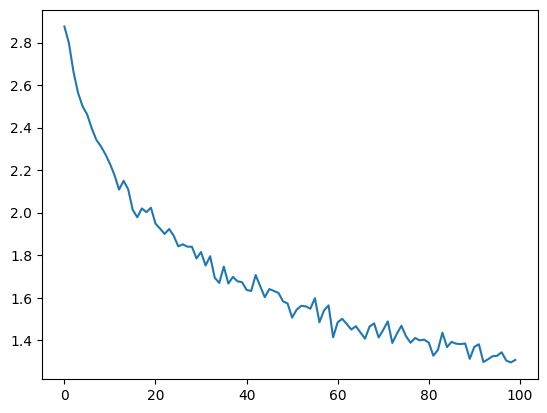

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
all_losses = trainer.all_losses
plt.plot(all_losses)

Note also that you can use TensorBoard to do this plotting.

**Evaluating the results**

To see how well the network performs on different categories, we will create a confusion matrix, indicating for every actual language (rows) which language the network guesses (columns). To calculate the confusion matrix a bunch of samples are run through the network with evaluate(), which is the same as fit() minus the backprop.

<ipython-input-14-1323284023>:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
<ipython-input-14-1323284023>:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


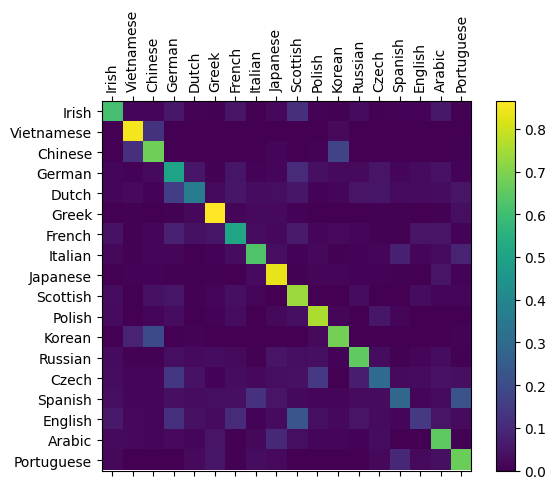

In [ ]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
  category, line, category_tensor, line_tensor = randomTrainingExample(all_categories, category_lines)
  output = rnn.evaluate(line_tensor)

  guess, guess_i = categoryFromOutput(output)
  category_i = all_categories.index(category)
  confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

To check whether the network performs well, the confusion matrix should have high values along the diagonal elements (ideally 1) and low values (ideally 0) in off-diagonal elements.

What do you think about the performance of your network? What can you do to improve it?

## **2. LSTM**

Now, update the code above so that instead of using a simple RNN, we will use LSTM. Start with one block LSTM and then try to cascade multiple LSTM blocks and compare the performance (e.g., by looking at the confusion matrix).

For using LSTM, please refer to this [LSTM tutorial](https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html). Make sure you implement it in a modular way following the structure we defined so far.

In [ ]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input_tensor):
        # input_tensor shape: (line_length, 1, n_letters)
        hidden = torch.zeros(self.num_layers, 1, self.hidden_size, device=input_tensor.device)
        cell = torch.zeros(self.num_layers, 1, self.hidden_size, device=input_tensor.device)
        out, (hn, cn) = self.lstm(input_tensor, (hidden, cell))
        output = self.fc(out[-1])  # Only the last output is used for classification
        return output

In [ ]:
def train_model(model, category_lines, all_categories, n_letters, learning_rate=0.005, n_iters=100000, print_every=5000):
    import random
    import time
    import math
    import torch.optim as optim

    criterion = nn.NLLLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    all_losses = []
    current_loss = 0
    model.train()

    def randomTrainingExample():
        category = random.choice(all_categories)
        line = random.choice(category_lines[category])
        category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
        line_tensor = lineToTensor(line)
        return category, line, category_tensor, line_tensor

    for iter in range(1, n_iters + 1):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        optimizer.zero_grad()
        output = model(line_tensor)
        loss = criterion(output, category_tensor)
        loss.backward()
        optimizer.step()

        current_loss += loss.item()
        if iter % print_every == 0:
            guess, guess_i = categoryFromOutput(output)
            correct = '✓' if guess == category else '✗ (%s)' % category
            print(f'{iter} {iter / n_iters * 100:.1f}% Loss: {loss.item():.4f} {line} / {guess} {correct}')
            all_losses.append(current_loss / print_every)
            current_loss = 0

    return all_losses

### **Evaluation and Comparison of LSTM vs Deep LSTM**

#Evaluation Function (external to training)#

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def evaluate_model(model, category_lines, all_categories, n_samples=1000):
    model.eval()
    y_true = []
    y_pred = []

    def randomTestExample():
        import random
        category = random.choice(all_categories)
        line = random.choice(category_lines[category])
        category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
        line_tensor = lineToTensor(line)
        return category, category_tensor, line_tensor

    with torch.no_grad():
        for _ in range(n_samples):
            category, category_tensor, line_tensor = randomTestExample()
            output = model(line_tensor)
            guess, guess_i = categoryFromOutput(output)
            y_true.append(all_categories.index(category))
            y_pred.append(guess_i)

    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=all_categories, zero_division=0))


#Train and Evaluate LSTM and Deep LSTM#

In [ ]:
# Train single-layer LSTM
print("Training 1-layer LSTM...")
lstm1 = LSTMClassifier(n_letters, 128, n_categories, num_layers=1)
train_model(lstm1, category_lines, all_categories, n_letters, n_iters=100000)

print("\nEvaluating 1-layer LSTM...")
evaluate_model(lstm1, category_lines, all_categories)

# Train deep (2-layer) LSTM
print("\nTraining 2-layer Deep LSTM...")
lstm2 = LSTMClassifier(n_letters, 128, n_categories, num_layers=2)
train_model(lstm2, category_lines, all_categories, n_letters, n_iters=100000)

print("\nEvaluating 2-layer Deep LSTM...")
evaluate_model(lstm2, category_lines, all_categories)


Training 1-layer LSTM...
5000 5.0% Loss: 2.9787  Taverna → Greek ✗ (Italian)
10000 10.0% Loss: 2.9740  Duong → Chinese ✗ (Vietnamese)
15000 15.0% Loss: 2.8720  Samson → English ✗ (Dutch)
20000 20.0% Loss: 2.7940  Tolkien → Scottish ✗ (German)
25000 25.0% Loss: 2.9361  Denis → Dutch ✗ (French)
30000 30.0% Loss: 0.8589  Protopsaltis → Greek ✓
35000 35.0% Loss: 3.0508  Longo → Korean ✗ (Italian)
40000 40.0% Loss: 1.7067  Zubizarreta → Spanish ✓
45000 45.0% Loss: 1.5810  Assaf → Arabic ✓
50000 50.0% Loss: 1.8294  Fuentes → Portuguese ✗ (Spanish)
55000 55.0% Loss: 0.0409  Kotsiopoulos → Greek ✓
60000 60.0% Loss: 2.9590  Lomas → Greek ✗ (English)
65000 65.0% Loss: 1.0140  Fionn → Irish ✓
70000 70.0% Loss: 1.4266  Mccallum → Irish ✗ (Scottish)
75000 75.0% Loss: 0.8303  O'Brien → Irish ✓
80000 80.0% Loss: 2.1719  Cahill → Irish ✗ (English)
85000 85.0% Loss: 0.0164  Ruzimatov → Russian ✓
90000 90.0% Loss: 1.2490  Tannous → Arabic ✓
95000 95.0% Loss: 0.3754  Ambrosi → Italian ✓
100000 100.0% Los